# Time-dependent toy example

Five-timestep electricity dispatch with a battery, demonstrating the time-indexed formulation in `pulpo.utils.time_extension` (exposed via `pulpo.pulpo_time.PulpoOptimizerTime`). The five steps represent a stylised day: early morning, mid-morning, midday, afternoon and evening.

## Storage logic at a glance

Following standard ESM practice, each storage technology is split into **four virtual activities** sharing a single intermediate product (the *charge product*):

| Activity | Ref. product | Inputs | Role |
|---|---|---|---|
| `CHARGE` | `charge_product` | 1 kWh electricity | Pumps grid electricity into storage |
| `HOLD` | `charge_product` | 1 unit `holdtm1_product` | In-step carrier of stored energy |
| `DISCHARGE` | `electricity, battery` | 1 unit `charge_product` | Releases electricity from storage |
| `HOLD t-1` | `holdtm1_product` | — (phantom) | Bridges *across* timesteps via `K` |

Both `CHARGE` and `HOLD` produce the *same* reference product `charge_product`. PULPO's `choices` mechanism unifies them into one virtual supplier, so `DISCHARGE` (which consumes 1 `charge_product`) sees a pool fed jointly by fresh charging *and* whatever was held over from the previous step.

The phantom activity `HOLD t-1` produces `holdtm1_product`. Its scaling at $t$ is locked to 0 (no "real" production), but the time-extension engine adds a carry-over supply of $K \cdot \text{(charge_product produced at } t{-}1\text{)}$. Because `holdtm1_product` is in `PRODUCT_STOR`, its time-balance is the inequality

$$
\underbrace{s_t^{\text{HOLD}}}_{\text{consumed by HOLD this step}} \;\le\; \underbrace{K \cdot \bigl(s_{t-1}^{\text{CHARGE}} + s_{t-1}^{\text{HOLD}} - s_{t-1}^{\text{DISCHARGE}}\bigr)}_{\text{carry-over from previous step}}
$$

— i.e. you can hold over at most `K` times the *net* charge product that was around at $t-1$. This is exactly the standard storage state-of-charge recurrence:

$$
SOC_t \;\le\; K \cdot (SOC_{t-1} + \text{charged}_{t-1} - \text{discharged}_{t-1}).
$$

See the engine code in [`time_extension.py:demand_constraint`](../pulpo/utils/time_extension.py) and the storage spec resolution in `instantiate_time`.

## What's in the toy database

* **`solar`** — produces 1 kWh `electricity, solar`, no emissions, bell-shaped capacity peaking at noon.
* **`coal`** — produces 1 kWh `electricity, coal`, emits 1 kg CO₂/kWh.
* **`battery_charge`** (`CHARGE`) — consumes 1 kWh grid electricity, produces 1 `charge_product`.
* **`battery_hold`** (`HOLD`) — consumes 1 `holdtm1_product`, produces 1 `charge_product`.
* **`battery_discharge`** (`DISCHARGE`) — consumes 1 `charge_product`, produces 1 kWh `electricity, battery`.
* **`battery_holdtm1`** (`HOLD t-1`) — phantom, ref product `holdtm1_product`, scaling locked at 0.

Demand is placed on a virtual `electricity` product, formed by `choices` over `{solar, coal, discharge}`. A second choice `charge_product` unifies `{charge, hold}`. Only `coal` emits CO₂; the only LCIA method is GWP100.

The storage spec is

```python
storage = [(battery_holdtm1, "charge_product", K)]
#          (target_product,    source_product, factor)
```

which tells PULPO: *the producers of `charge_product` at $t{-}1$ supply $K$ units of `holdtm1_product` at $t$*. `K` is the round-trip retention factor: `K = 1.0` lossless, `K < 1.0` lossy, `K = None` disables storage entirely.

In [1]:
import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pulpo import pulpo_time
from pulpo.datasets.elec_time_database import (
    setup_elec_time_db,
    PROJECT_NAME, DB_NAME,
    SOLAR_KEY, COAL_KEY,
    BATTERY_CHARGE_KEY, BATTERY_HOLD_KEY,
    BATTERY_DISCHARGE_KEY, BATTERY_HOLDTM1_KEY,
    CHARGE_PRODUCT_CHOICE,
)

setup_elec_time_db()
bd.projects.set_current(PROJECT_NAME)
db = bd.Database(DB_NAME)

solar     = next(a for a in db if a.key == SOLAR_KEY)
coal      = next(a for a in db if a.key == COAL_KEY)
charge    = next(a for a in db if a.key == BATTERY_CHARGE_KEY)
hold      = next(a for a in db if a.key == BATTERY_HOLD_KEY)
discharge = next(a for a in db if a.key == BATTERY_DISCHARGE_KEY)
holdtm1   = next(a for a in db if a.key == BATTERY_HOLDTM1_KEY)


[elec_time_toy] project='elec_time_toy', db='elec_time_toy_db', activities=6, methods=[('GWP', '100a')]


## Define the time-dependent problem

Solar capacity follows a bell shape peaking at noon. Demand is moderate during the day and rises in the evening when there is no sun left. Coal is always available but expensive in CO2 terms.

In [2]:
GWP100 = str(("GWP", "100a"))

time_steps = [0, 1, 2, 3, 4]
step_labels = ["early\nmorning", "mid-\nmorning", "midday", "after-\nnoon", "evening"]

solar_cap  = {0:  10.0, 1:  80.0, 2: 120.0, 3:  60.0, 4:   0.0}
demand_kwh = {0:  50.0, 1:  60.0, 2:  60.0, 3:  160.0, 4: 100.0}

choices = {
    "electricity":         {solar: 1e6, coal: 1e6, discharge: 1e6},
    CHARGE_PRODUCT_CHOICE: {charge: 1e6, hold: 1e6},
}

# Per-timestep capacities. Discharge is locked at t=0 (battery starts empty).
# `holdtm1` is the phantom carrier - its scaling is locked at 0; the supply at
# t comes purely from K * (charge_product produced at t-1).
upper_limit = {
    t: {
        solar: solar_cap[t],
        coal: 1e6,
        charge: 1e6,
        hold: 1e6,
        discharge: 0.0 if t == 0 else 1e6,
        holdtm1: 0.0,
    }
    for t in time_steps
}

# Battery flows must be physically non-negative. The default lower bound is
# -inf, which would let the optimizer run charging/holding at a negative level
# (effectively a free electricity source, since they are sinks).
lower_limit = {
    t: {charge: 0.0, hold: 0.0, discharge: 0.0}
    for t in time_steps
}

demand = {t: {"electricity": demand_kwh[t]} for t in time_steps}


### Visualize the inputs

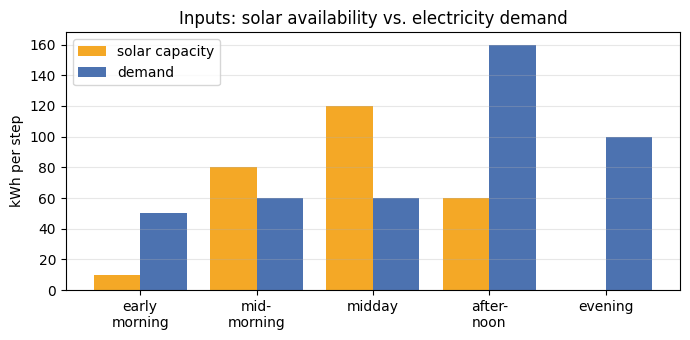

In [3]:
x = np.arange(len(time_steps))
width = 0.4

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(x - width/2, [solar_cap[t]  for t in time_steps], width,
       label="solar capacity", color="#f4a826")
ax.bar(x + width/2, [demand_kwh[t] for t in time_steps], width,
       label="demand",          color="#4c72b0")
ax.set_xticks(x); ax.set_xticklabels(step_labels)
ax.set_ylabel("kWh per step")
ax.set_title("Inputs: solar availability vs. electricity demand")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

## Solve three scenarios

1. **No battery** — storage disabled (`K = None`, no triple passed).
2. **Lossy battery** ($K = 0.3$) — carry-over with heavy retention losses.
3. **Ideal battery** ($K = 1.0$) — lossless upper bound.

**Why the lower bounds matter.** The default lower bound on activity scaling is $-\infty$. Charging and holding are *sinks* of electricity / `charge_product`, so a negative scaling would behave as a free source. We pin `charge[t], hold[t], discharge[t] ≥ 0` for every step.

**Multi-step carry-over.** With the explicit `HOLD` activity, the state-of-charge propagates naturally across many steps: surplus solar at $t{=}2$ goes into `charge`; at $t{=}3$ that energy appears as `holdtm1_product`, gets carried forward by `hold`, and at $t{=}3$ or later is drawn down by `discharge`. The retention factor $K$ is paid *once per held step*, so holding for $n$ steps gives effective efficiency $K^n$.

In [4]:
def solve_scenario(label, *, K):
    storage_spec = [(holdtm1, CHARGE_PRODUCT_CHOICE, K)] if K is not None else None
    w = pulpo_time.PulpoOptimizerTime(PROJECT_NAME, DB_NAME, {GWP100: 1}, ".")
    w.get_lci_data()
    w.instantiate(
        choices=choices,
        demand=demand,
        upper_limit=upper_limit,
        lower_limit=lower_limit,
        time_steps=time_steps,
        storage=storage_spec,
    )
    w.solve()
    pmap = w.lci_data["process_map"]
    df = pd.DataFrame(
        {
            name: [w.instance.scaling_vector[t, pmap[act.key]].value for t in time_steps]
            for name, act in [("solar", solar), ("coal", coal),
                              ("charge", charge), ("hold", hold),
                              ("discharge", discharge)]
        },
        index=step_labels,
    )
    df["co2"] = [w.instance.impacts[t, GWP100].value for t in time_steps]
    df.attrs["label"] = label
    df.attrs["K"] = K
    df.attrs["total_co2"] = float(df["co2"].sum())
    return w, df

_, df_nobattery = solve_scenario("no battery",            K=None)
_, df_battery   = solve_scenario("battery (K = 0.3)",      K=0.3)
_, df_ideal     = solve_scenario("ideal battery (K = 1.0)", K=1.0)

for df in (df_nobattery, df_battery, df_ideal):
    print(f"  {df.attrs['label']:30s}  total CO2 = {df.attrs['total_co2']:7.2f} kg")


Creating time-indexed instance
Time-indexed instance created
optimal solution found:  240.0
Creating time-indexed instance
Time-indexed instance created
optimal solution found:  220.2
Creating time-indexed instance
Time-indexed instance created
optimal solution found:  160.0
  no battery                      total CO2 =  240.00 kg
  battery (K = 0.3)               total CO2 =  220.20 kg
  ideal battery (K = 1.0)         total CO2 =  160.00 kg


### Visualize the dispatch

Each subplot has two halves:

* **Above zero — supply meeting demand.** Stacked bars show how the demand
  at each step is met: `solar` + `coal` produced this step, plus `discharge`
  drawn out of the battery. The black tick marks the demand level.
* **Below zero — electricity diverted into storage.** The hatched green bar
  is `charge` (fresh electricity going *into* the battery). It is plotted
  downward to emphasise that it is a sink, not a supply. Per-step balance:
  `solar + coal = demand_met_directly + charge`.

The dashed line shows the **state of charge** entering each step, i.e. the
`holdtm1_product` available at $t$. Concretely, with $K$ the retention factor,


$$$$
SOC_t \;=\; K \cdot (SOC_{t-1} + \text{charge}_{t-1} - \text{discharge}_{t-1}).

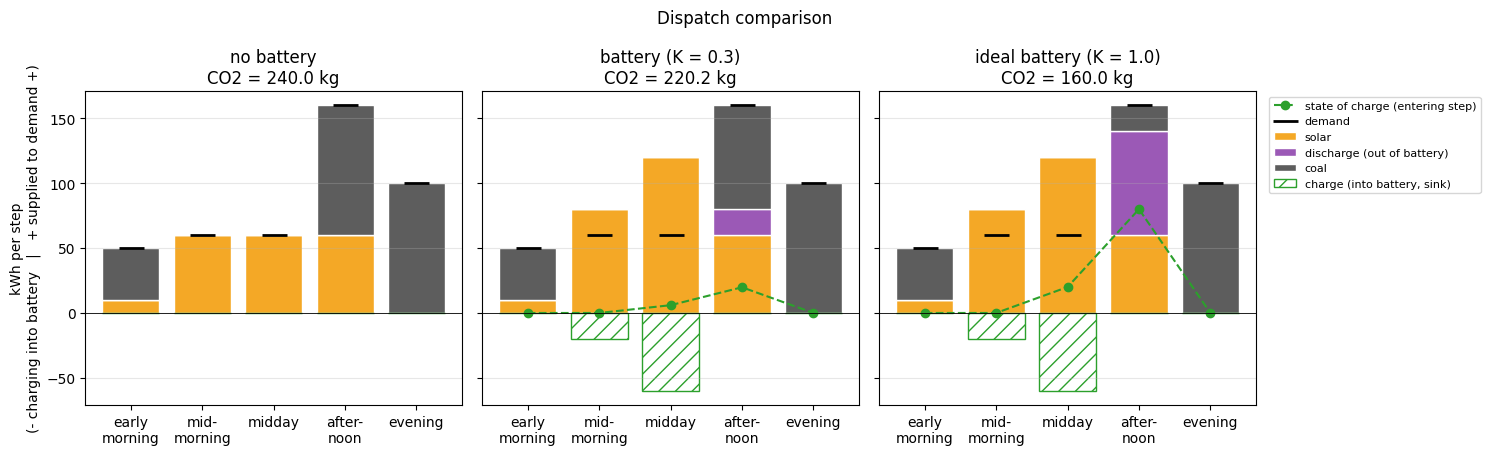

In [5]:
def stored_energy_series(df):
    """State of charge entering each step (= holdtm1_product available at t).

    SOC_t = K * (SOC_{t-1} + charge_{t-1} - discharge_{t-1}), SOC_0 = 0.
    """
    K = df.attrs["K"] or 0.0
    soc = [0.0]
    for t in range(len(df) - 1):
        soc.append(K * (soc[-1] + df["charge"].iloc[t] - df["discharge"].iloc[t]))
    return soc

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, df in zip(axes, [df_nobattery, df_battery, df_ideal]):
    # --- Supply side (positive): stacks up to meet demand ---
    bottoms = np.zeros(len(time_steps))
    for col, color, label in [
        ("solar",     "#f4a826", "solar"),
        ("discharge", "#9b59b6", "discharge (out of battery)"),
        ("coal",      "#5d5d5d", "coal"),
    ]:
        vals = df[col].values
        ax.bar(x, vals, bottom=bottoms, label=label, color=color, edgecolor="white")
        bottoms = bottoms + vals

    # --- Storage side (negative): electricity diverted into the battery ---
    charge_vals = df["charge"].values
    ax.bar(x, -charge_vals, bottom=0.0, label="charge (into battery, sink)",
           color="none", edgecolor="#2ca02c", hatch="//", linewidth=1.0)

    # State of charge entering each step
    if df.attrs["K"] is not None:
        ax.plot(x, stored_energy_series(df), "o--", color="#2ca02c",
                label="state of charge (entering step)")

    # Demand reference line
    ax.plot(x, [demand_kwh[t] for t in time_steps], "k_", markersize=18,
            markeredgewidth=2, label="demand")

    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels(step_labels)
    ax.set_title(f"{df.attrs['label']}\nCO2 = {df.attrs['total_co2']:.1f} kg")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("kWh per step\n(- charging into battery   |   + supplied to demand +)")
axes[-1].legend(loc="upper left", fontsize=8, bbox_to_anchor=(1.02, 1.0))
fig.suptitle("Dispatch comparison")
fig.tight_layout(); plt.show()
